# Iris Flower Classification

## Oasis Infobyte Data Science Internship — Task 1

### Objective
Build a machine learning classification model to identify the species of an iris flower
(Setosa, Versicolor, or Virginica) based on its physical measurements.

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

***Step 2: Import Libraries***

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


***Step 3 — Iris Dataset Load***

In [2]:
# Load the Iris dataset
iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


***Step 4 — Create a DataFrame from the Iris dataset***

In [3]:
# Create a DataFrame from the Iris dataset
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


***Step 5 — Data Understanding / EDA***

In [4]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (150, 5)


***Step 6 — Data Types***

In [5]:
# Check data types of each column
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

***Step 7 — Missing Values***

In [6]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


***Step 8 — Descriptive Statistics***

In [7]:
# Generate descriptive statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


***Step 9 — Map target numbers to species names***

In [8]:
# Map target numbers to species names
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


***Step 10 — Species Count***

In [9]:
print("Number of samples in each species:")
print(df["species"].value_counts())

Number of samples in each species:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


***Step 11 — Pairplot***

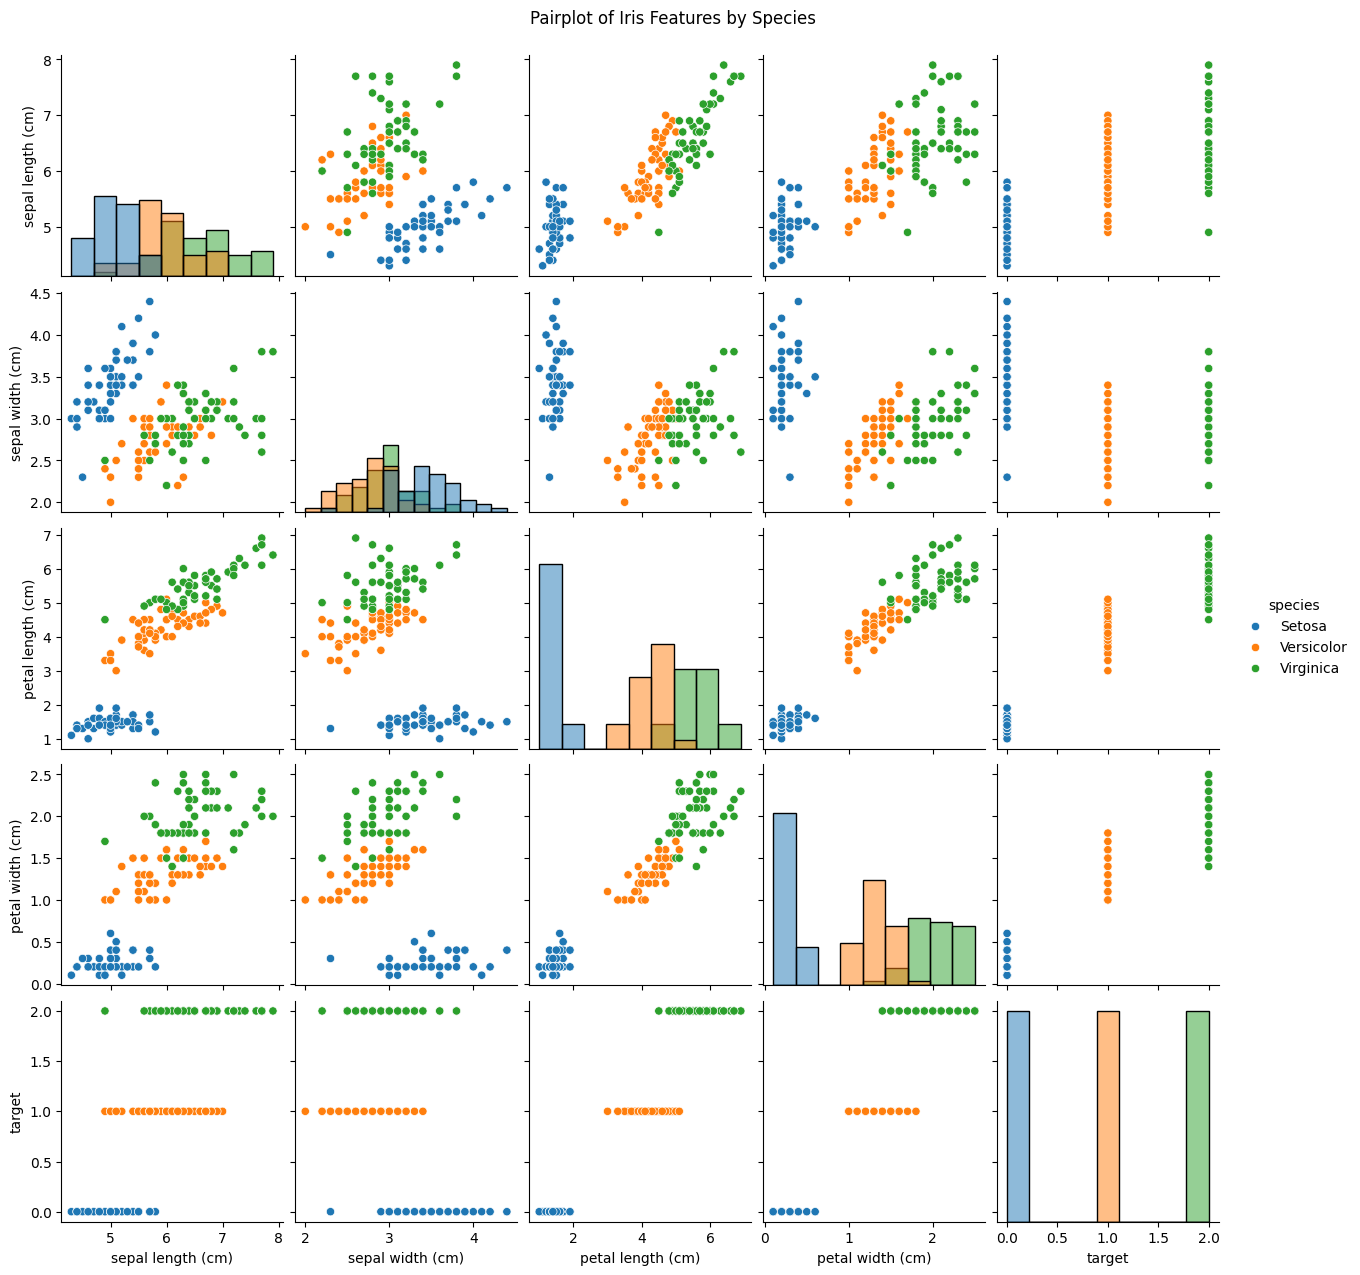

In [10]:
sns.pairplot(df, hue="species", diag_kind="hist")

plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

***Step 12 — Boxplots***

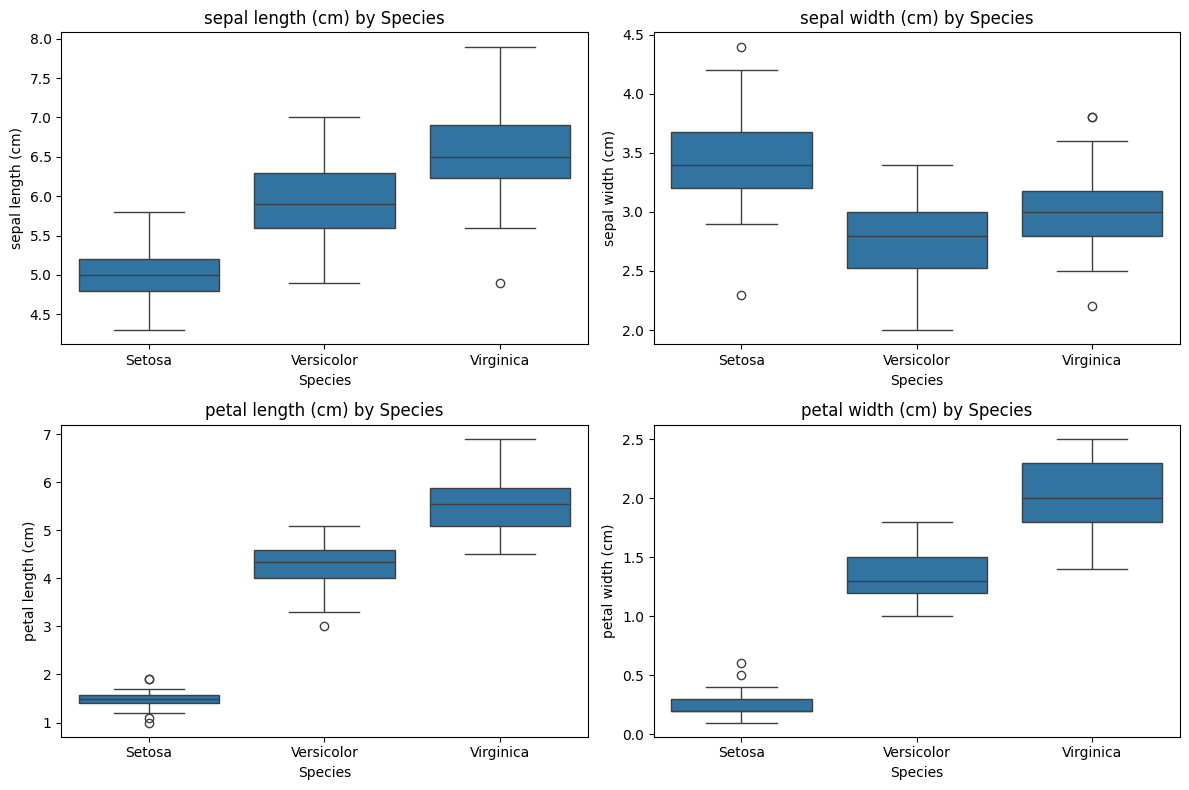

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = iris.feature_names

for ax, feature in zip(axes.flat, features):
    sns.boxplot(data=df, x="species", y=feature, ax=ax)
    ax.set_title(f"{feature} by Species")
    ax.set_xlabel("Species")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

***Step 13 — Feature Selection Discussion***

## Feature Selection Discussion

Based on the visualizations, the petal-related features show clearer differences
between the three iris species compared with the sepal-related features.

Petal length and petal width provide strong visual separation between species,
while sepal measurements show comparatively more overlap.

For the classification models, all four available features will be used as input
features so that the models can learn from the complete dataset.

***Step 14 — Define X and y***

In [19]:
X = df[iris.feature_names]
y = df["target"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


***Step 15 — Train-Test Split***

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


***Step 16 — Logistic Regression***

In [23]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [24]:
LogisticRegression()

LogisticRegression()

***Step 17 — Make Predictions***

In [26]:
# Predict the species for test data
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions:")
print(y_pred_logistic)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


***Step 18 — Accuracy***

In [27]:
from sklearn.metrics import accuracy_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)
print("Accuracy (%):", accuracy_logistic * 100)

Logistic Regression Accuracy: 0.9666666666666667
Accuracy (%): 96.66666666666667


***Step 19 — Confusion Matrix***

In [28]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


***Step 20 — Confusion Matrix Heatmap***

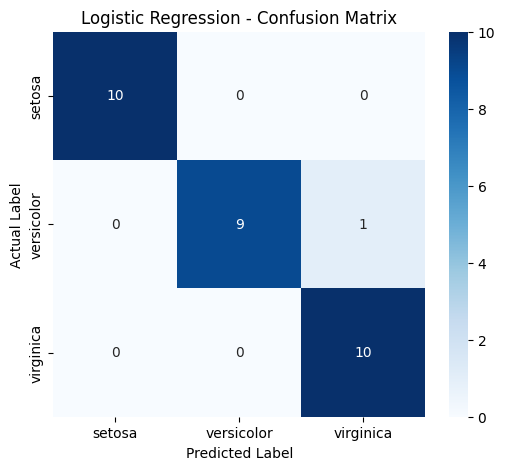

In [29]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

***Step 21 — Classification Report***

In [30]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



***Step 22 — KNN Model***

In [32]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

***Step 23 — KNN Predictions***

In [33]:
# Predict the species for test data
y_pred_knn = knn_model.predict(X_test)

print("KNN Predictions:")
print(y_pred_knn)

KNN Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


***Step 24 — KNN Accuracy***

In [34]:
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("Accuracy (%):", accuracy_knn * 100)

KNN Accuracy: 1.0
Accuracy (%): 100.0


***Step 25 — KNN Confusion Matrix***

In [35]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

KNN Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


***Step 26 — KNN Classification Report***

In [36]:
from sklearn.metrics import classification_report

print("KNN Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



***Step 27 — Model Comparison Table****

In [37]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_logistic,
        accuracy_knn
    ]
})

model_comparison["Accuracy (%)"] = model_comparison["Accuracy"] * 100

model_comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,KNN,1.000000,100.000000


***Step 28 — Best Model***

## Best Model Selection

Based on the evaluation results, K-Nearest Neighbors (KNN) performed better than
Logistic Regression on the test dataset.

- Logistic Regression Accuracy: 96.67%
- KNN Accuracy: 100%

Therefore, KNN is selected as the best-performing model for this classification
task based on the test-set accuracy.

***Step 29 — Final Conclusion.****

## Conclusion

In this project, an Iris Flower Classification model was developed using
machine learning techniques.

The Iris dataset was explored using descriptive statistics, pairplots, and
boxplots. The data was divided into 80% training data and 20% testing data.

Two classification algorithms were implemented:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)

The models were evaluated using accuracy, confusion matrix, precision, recall,
and F1-score.

### Model Results

- Logistic Regression achieved an accuracy of 96.67%.
- KNN achieved an accuracy of 100%.

Based on the test-set results, KNN was the best-performing model for this
classification task.

The KNN model correctly classified all 30 samples in the test dataset.

***Step 30 — Training vs Testing Accuracy***

In [39]:
# Logistic Regression: Training vs Testing Accuracy

logistic_train_accuracy = logistic_model.score(X_train, y_train)
logistic_test_accuracy = logistic_model.score(X_test, y_test)

print("Logistic Regression Training Accuracy:",
      logistic_train_accuracy)

print("Logistic Regression Testing Accuracy:",
      logistic_test_accuracy)

print("Accuracy Gap:",
      logistic_train_accuracy - logistic_test_accuracy)

Logistic Regression Training Accuracy: 0.975
Logistic Regression Testing Accuracy: 0.9666666666666667
Accuracy Gap: 0.008333333333333304


***Step 31 — KNN Training vs Testing Accuracy***

In [40]:
# KNN: Training vs Testing Accuracy

knn_train_accuracy = knn_model.score(X_train, y_train)
knn_test_accuracy = knn_model.score(X_test, y_test)

print("KNN Training Accuracy:",
      knn_train_accuracy)

print("KNN Testing Accuracy:",
      knn_test_accuracy)

print("Accuracy Gap:",
      knn_train_accuracy - knn_test_accuracy)

KNN Training Accuracy: 0.9666666666666667
KNN Testing Accuracy: 1.0
Accuracy Gap: -0.033333333333333326


***Step 32 — Cross-Validation***

In [41]:
from sklearn.model_selection import cross_val_score

# Logistic Regression Cross-Validation
logistic_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

# KNN Cross-Validation
knn_cv_scores = cross_val_score(
    knn_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:")
print(logistic_cv_scores)

print("\nKNN CV Scores:")
print(knn_cv_scores)

Logistic Regression CV Scores:
[0.96666667 1.         0.93333333 0.96666667 1.        ]

KNN CV Scores:
[0.96666667 1.         0.93333333 0.96666667 1.        ]


***Step 33 — Cross-Validation Mean & Standard Deviation***

In [42]:
# Mean and Standard Deviation of Cross-Validation Scores

logistic_cv_mean = logistic_cv_scores.mean()
logistic_cv_std = logistic_cv_scores.std()

knn_cv_mean = knn_cv_scores.mean()
knn_cv_std = knn_cv_scores.std()

print("Logistic Regression:")
print("Mean CV Accuracy:", logistic_cv_mean)
print("CV Standard Deviation:", logistic_cv_std)

print("\nKNN:")
print("Mean CV Accuracy:", knn_cv_mean)
print("CV Standard Deviation:", knn_cv_std)

Logistic Regression:
Mean CV Accuracy: 0.9733333333333334
CV Standard Deviation: 0.02494438257849294

KNN:
Mean CV Accuracy: 0.9733333333333334
CV Standard Deviation: 0.02494438257849294


***Step 34 — Feature Scaling + KNN***

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Create a pipeline with scaling + KNN
knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# Train the scaled KNN model
knn_scaled.fit(X_train, y_train)

# Prediction
y_pred_knn_scaled = knn_scaled.predict(X_test)

# Accuracy
knn_scaled_accuracy = accuracy_score(y_test, y_pred_knn_scaled)

print("Scaled KNN Accuracy:", knn_scaled_accuracy)
print("Scaled KNN Accuracy (%):", knn_scaled_accuracy * 100)

Scaled KNN Accuracy: 0.9333333333333333
Scaled KNN Accuracy (%): 93.33333333333333


***Step 35 — KNN Hyperparameter Tuning***

In [44]:
from sklearn.model_selection import GridSearchCV

# Different k values try karenge
param_grid = {
    "knn__n_neighbors": range(1, 16)
}

grid_search = GridSearchCV(
    knn_scaled,
    param_grid,
    cv=5,
    scoring="accuracy"
)

# Train only on training data
grid_search.fit(X_train, y_train)

# Best model
best_knn = grid_search.best_estimator_

# Best k and CV accuracy
best_k = grid_search.best_params_["knn__n_neighbors"]
best_cv_accuracy = grid_search.best_score_

# Test accuracy
best_knn_pred = best_knn.predict(X_test)
best_knn_test_accuracy = accuracy_score(y_test, best_knn_pred)

print("Best k:", best_k)
print("Best CV Accuracy:", best_cv_accuracy)
print("Best KNN Test Accuracy:", best_knn_test_accuracy)
print("Best KNN Test Accuracy (%):", best_knn_test_accuracy * 100)

Best k: 5
Best CV Accuracy: 0.9666666666666668
Best KNN Test Accuracy: 0.9333333333333333
Best KNN Test Accuracy (%): 93.33333333333333


***Step 36 — Final Model Comparison***

In [45]:
# Final Model Comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Original KNN",
        "Scaled KNN",
        "Tuned Scaled KNN"
    ],
    "Test Accuracy (%)": [
        logistic_test_accuracy * 100,
        knn_test_accuracy * 100,
        knn_scaled_accuracy * 100,
        best_knn_test_accuracy * 100
    ]
})

final_comparison

,Model,Test Accuracy (%)
0,Logistic Regression,96.666667
1,Original KNN,100.000000
2,Scaled KNN,93.333333
3,Tuned Scaled KNN,93.333333


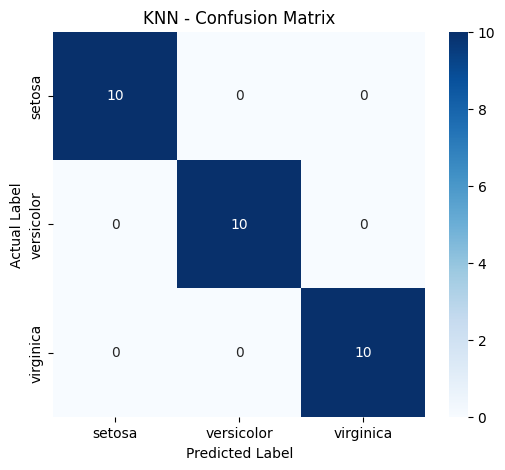

In [46]:
# KNN Confusion Matrix Heatmap

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

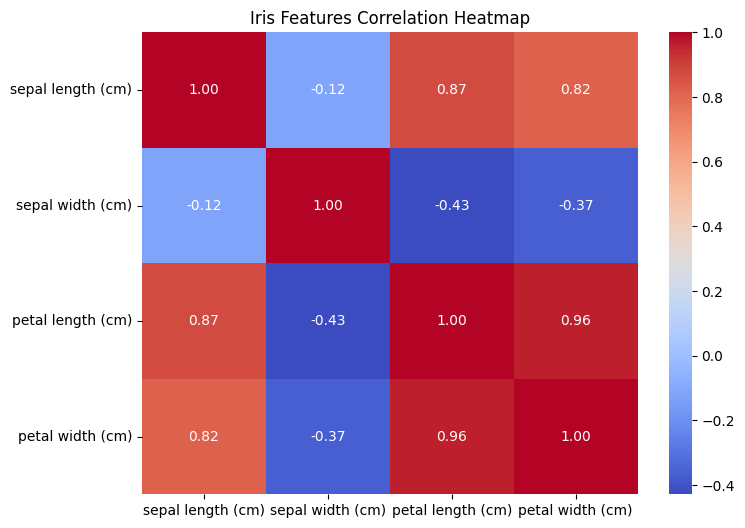

In [47]:
# Feature Correlation Heatmap

plt.figure(figsize=(8, 6))

correlation = df[iris.feature_names].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Iris Features Correlation Heatmap")
plt.show()

# Iris Flower Classification

## Import Libraries
## Load Dataset
## Create DataFrame

## Exploratory Data Analysis
### Dataset Shape
### Data Types
### Missing Values
### Descriptive Statistics
### Species Distribution

## Data Visualization
### Pairplot
### Boxplots
### Correlation Heatmap

## Feature Selection Discussion

## Train-Test Split

## Model 1 - Logistic Regression
### Prediction
### Accuracy
### Confusion Matrix
### Classification Report

## Model 2 - KNN
### Prediction
### Accuracy
### Confusion Matrix
### Classification Report

## Model Comparison

## Overfitting and Underfitting Check
### Training vs Testing Accuracy
### Cross-Validation

## Feature Scaling
### Scaled KNN

## Hyperparameter Tuning
### Best K Value

## Best Model Selection

## Final Model Evaluation

## Conclusion